<a href="https://colab.research.google.com/github/usmanshaikh90044-creator/Personal-spending-forecasting/blob/main/LSTM_spending_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import matplotlib.pyplot as plt


📌 **Introduction**

This project analyzes and forecasts my personal spending using data extracted from Google Pay through Google Takeout. The raw transaction history was provided in HTML format, so I first used Python to convert it into a clean CSV file for analysis. After preprocessing the data—keeping only completed outgoing transactions and aggregating it by date—I explored whether time-series models could predict future spending. The goal was to build and test an LSTM model, and later compare it with Prophet/NeuralProphet to understand how well different approaches can handle real-world, irregular financial data.

In [44]:
df = pd.read_csv(r'/content/extracted_gpay_data.csv')
df

,source_file,transaction_type,direction,status,amount_inr,currency,counterparty,category_guess,payment_instrument,account_last4,datetime_local,date,time,time_24h,weekday,month,year,product,details_id,raw_text
0,My Activity.html,Paid,outgoing,Completed,160.0,INR,METRO CHEMIST AND DRUGIST,Medical,Bank Account XXXXXX4994,4994.0,2025-08-13T17:44:51-05:30,13-08-2025,5:44:51 PM,17:44:51,Wednesday,2025-08,2025,Google Pay,eVWoBcpRQ/yklwth,Paid ₹160.00 to METRO CHEMIST AND DRUGIST usin...
1,My Activity.html,Paid,outgoing,Completed,10.0,INR,DINESH SAHU,NaN,Bank Account XXXXXX4994,4994.0,2025-08-13T17:28:21-05:30,13-08-2025,5:28:21 PM,17:28:21,Wednesday,2025-08,2025,Google Pay,#NAME?,Paid ₹10.00 to DINESH SAHU using Bank Account ...
2,My Activity.html,Paid,outgoing,Completed,450.0,INR,NaN,NaN,Bank Account XXXXXX4994,4994.0,2025-08-12T15:45:39-05:30,12-08-2025,3:45:39 PM,15:45:39,Tuesday,2025-08,2025,Google Pay,PKJH/xfiTOKPlPNl,Paid ₹450.00 using Bank Account XXXXXX4994
3,My Activity.html,Received,incoming,Completed,500.0,INR,NaN,NaN,NaN,NaN,2025-08-12T15:44:28-05:30,12-08-2025,3:44:28 PM,15:44:28,Tuesday,2025-08,2025,Google Pay,Dx9tyUVuSTWgloOb,Received ₹500.00
4,My Activity.html,Received,incoming,Failed,500.0,INR,NaN,NaN,NaN,NaN,2025-08-12T15:44:16-05:30,12-08-2025,3:44:16 PM,15:44:16,Tuesday,2025-08,2025,Google Pay,WMhLUMlFS1e4JkkM,Received ₹500.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,My Activity.html,Received,incoming,Completed,1000.0,INR,NaN,NaN,NaN,NaN,2022-03-15T10:46:44-05:30,15-03-2022,10:46:44 AM,10:46:44,Tuesday,2022-03,2022,Google Pay,0ZRsRBA+RrKCxA7d,Received ₹1000.00
2044,My Activity.html,Received,incoming,Failed,1000.0,INR,NaN,NaN,NaN,NaN,2022-03-15T10:46:22-05:30,15-03-2022,10:46:22 AM,10:46:22,Tuesday,2022-03,2022,Google Pay,S8Gvqn7rSHCeSQMW,Received ₹1000.00
2045,My Activity.html,Received,incoming,Completed,10.0,INR,NaN,NaN,NaN,NaN,2022-03-14T23:57:53-05:30,14-03-2022,11:57:53 PM,23:57:53,Monday,2022-03,2022,Google Pay,U9EaTnnbTt+othdE,Received ₹10.00
2046,My Activity.html,Sent,outgoing,Completed,9.0,INR,NaN,NaN,Bank Account XXXXXX4994,4994.0,2022-03-14T23:20:57-05:30,14-03-2022,11:20:57 PM,23:20:57,Monday,2022-03,2022,Google Pay,Dg40Azw/SNqscw7p,Sent ₹9.00 using Bank Account XXXXXX4994


In [45]:
df.columns

Index(['source_file', 'transaction_type', 'direction', 'status', 'amount_inr',
       'currency', 'counterparty', 'category_guess', 'payment_instrument',
       'account_last4', 'datetime_local', 'date', 'time', 'time_24h',
       'weekday', 'month', 'year', 'product', 'details_id', 'raw_text'],
      dtype='object')

In [46]:
df.status.value_counts()

,count
status,
Completed,1921
Failed,62
Pending,18
No Status Found,17
Cancelled,13


In [47]:
#taking only the completed transactions into consideration


# Standardizing cause the data can be like (Completed or COMPLETED etc)
df['status'] = df['status'].astype(str).str.strip().str.lower()


df = df[df['status'] == 'completed'].reset_index(drop=True)


print(df['status'].value_counts())



status
completed    1921
Name: count, dtype: int64


In [48]:
#keeping only the expense transaction
df['transaction_type'] = df['transaction_type'].astype(str).str.strip().str.lower()

# Keep only outgoing money transactions
df = df[df['transaction_type'].isin(['sent', 'paid'])]

print(df['transaction_type'].value_counts())


transaction_type
paid    1387
sent     314
Name: count, dtype: int64


In [49]:
#analyzing the data
df.describe()

,amount_inr,account_last4,year
count,1701.000000,1701.0,1701.000000
mean,505.540412,4994.0,2024.401529
std,3863.457028,0.0,0.741523
min,1.000000,4994.0,2022.000000
25%,10.000000,4994.0,2024.000000
50%,30.000000,4994.0,2025.000000
75%,120.000000,4994.0,2025.000000
max,80000.000000,4994.0,2025.000000


**Insights :**

* My Avg spending = 505
* My Max amount spent at once was 80000 & Min = 1
* 75% of My transactions are below ₹120
* 50% below ₹30

In [50]:
df.dtypes

,0
source_file,object
transaction_type,object
direction,object
status,object
amount_inr,float64
currency,object
counterparty,object
category_guess,object
payment_instrument,object
account_last4,float64


In [51]:
#converting the date datatype into datetime
df['date']=pd.to_datetime(df['date'])
df.dtypes

/tmp/ipython-input-595169613.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date']=pd.to_datetime(df['date'])


,0
source_file,object
transaction_type,object
direction,object
status,object
amount_inr,float64
currency,object
counterparty,object
category_guess,object
payment_instrument,object
account_last4,float64


In [52]:
df['date'].min(),df['date'].max()  #ie from 14/03/2022 to 13/08/2025

(Timestamp('2022-03-14 00:00:00'), Timestamp('2025-08-13 00:00:00'))

**Preprocessing for the LSTM model**

In [53]:
#Step 1 :- Single dimensional data
df = df[["date","amount_inr"]]
df

,date,amount_inr
0,2025-08-13,160.0
1,2025-08-13,10.0
2,2025-08-12,450.0
4,2025-08-12,170.0
5,2025-08-11,20.0
...,...,...
1912,2022-04-16,50.0
1914,2022-03-21,10.0
1915,2022-03-16,20.0
1919,2022-03-14,9.0


In [54]:
#Step 2 :- sorting the data in asc order using the date col

df=df.sort_values('date')
df.isnull().sum()

,0
date,0
amount_inr,0


In [55]:
#Step 3 :- there should be only one value in one date

df.date.value_counts()

,count
date,
2025-02-07,15
2025-03-31,13
2025-06-14,12
2024-08-04,10
2024-12-28,10
...,...
2025-03-07,1
2024-02-05,1
2024-01-30,1


In [56]:
df=df.groupby('date')['amount_inr'].sum().reset_index()  #we basically added all the transactions belonging to one date
df.date.value_counts()

,count
date,
2022-03-14,1
2025-01-28,1
2025-01-22,1
2025-01-23,1
2025-01-24,1
...,...
2024-05-20,1
2024-05-19,1
2024-05-18,1


In [57]:
#step 4 :- set the index to  date

df=df.set_index('date')


In [58]:
df.head()

,amount_inr
date,
2022-03-14,10.0
2022-03-16,20.0
2022-03-21,10.0
2022-04-16,50.0
2022-04-20,100.0


In [59]:
#Steap 5 :- Resampling

y = df['amount_inr'].resample("ME").sum()

In [60]:
y.shape

(42,)

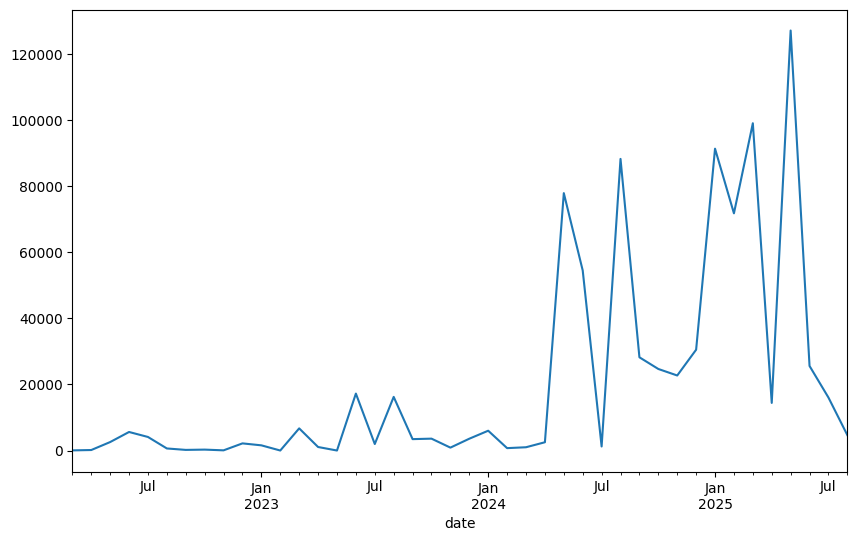

In [61]:
y.plot(figsize=(10,6))
plt.show()

In [62]:
#step 6: scalling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

values = y.values.reshape(-1, 1)
scaled_values = scaler.fit_transform(values)

In [63]:
#step 7 window creation
WINDOW_SIZE = 12   # it can be anything basically thisis how LSTM model learns

X = []  #X is basically the seq of past value
y = []  #y is basically value after those seq

for i in range(WINDOW_SIZE, len(scaled_values)):
    X.append(scaled_values[i-WINDOW_SIZE:i, 0])  # past 12 weeks
    y.append(scaled_values[i, 0])                # next week value

import numpy as np
X = np.array(X)
y = np.array(y)

# Reshape for LSTM: (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)


Creating train test split manually

In [64]:
TEST_SIZE = 12  # last 12 weeks for testing

X_train = X[:-TEST_SIZE]
X_test  = X[-TEST_SIZE:]

y_train = y[:-TEST_SIZE]
y_test  = y[-TEST_SIZE:]



**Building the LSTM Model**

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 467ms/step - loss: 0.0024 - val_loss: 0.2184
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0019 - val_loss: 0.2070
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0021 - val_loss: 0.2173
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0021 - val_loss: 0.2278
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0018 - val_loss: 0.2358
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0014 - val_loss: 0.2384
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0018 - val_loss: 0.2348
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0022 - val_loss: 0.2294
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0021 - val_loss: 0.2265
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0020 - val_loss: 0.2272
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0017 - val_loss: 0.2315
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0017 - val_l

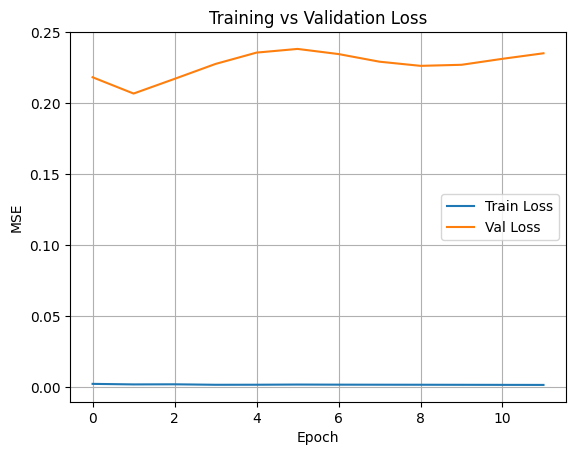

In [67]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


In [68]:
y_pred_scaled = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


In [69]:
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


In [70]:
y_pred_scaled = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [71]:
# Reshape because inverse_transform requires 2D
y_test_scaled_2d = y_test.reshape(-1, 1)
y_pred_scaled_2d = y_pred_scaled.reshape(-1, 1)

# Convert back to actual INR values
y_test_actual = scaler.inverse_transform(y_test_scaled_2d).flatten()
y_pred_actual = scaler.inverse_transform(y_pred_scaled_2d).flatten()


**SUMMARY**

Developed and trained an LSTM-based time series forecasting model on weekly and monthly spending data with full preprocessing, scaling, and sequence generation. The dataset showed irregular patterns with sudden spikes and no consistent trend or seasonality, making pattern learning challenging. Both time resolutions were impacted by this behavior. Proposed enhancements include exploring alternative models like Prophet for improved handling of irregular time-series data.

**Trying the Prophet Model**

In [75]:
y_unscaled = df['amount_inr'].resample('MS').sum()  #prophet requires the unscalled value cause its not a neural network



In [76]:
df_prophet = y_unscaled.reset_index()
df_prophet.columns = ['ds', 'y']


Due to environment issues with the original Prophet (Stan backend), I used NeuralProphet, a neural-network-based extension that follows the same additive forecasting philosophy as Prophet.

In [77]:
!pip install neuralprophet


In [78]:
from neuralprophet import NeuralProphet

model = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)

# Key: set learning_rate and disable checkpointing
metrics = model.fit(
    df_prophet,
    freq='MS',
    learning_rate=1e-3,      # any reasonable LR, e.g. 1e-3
    checkpointing=False,     # avoids the torch.load error
    progress='bar'           # optional, just for a nice progress bar
)

future = model.make_future_dataframe(df=df_prophet, periods=12)
forecast = model.predict(future)


ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [97.619]% of the data.
INFO:NP.df_utils:Major frequency MS corresponds to [97.619]% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be remo

Training: 0it [00:00, ?it/s]

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [97.619]% of the data.
INFO:NP.df_utils:Major frequency MS corresponds to [97.619]% of the data.
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/loc

Predicting: 6it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


In [79]:
#plotting
model.plot(forecast)
model.plot_components(forecast)


WARNING - (NP.plotting.log_warning_resampler_switch_to_valid_env) - Warning: plotly-resampler not supported for the environment you are using. Plotting backend automatically switched to 'plotly' without resampling 
WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/plot_forecast_plotly.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fcst = fcst.fillna(value=np.nan)

  fcst = fcst.fillna(value=np.nan)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behav

The NeuralProphet model was trained on monthly spending data to forecast future expenses using a trend and seasonality decomposition approach similar to Prophet. Due to the highly irregular nature of the data—characterized by extended low-spending periods and sudden extreme spikes—the model faced challenges in learning consistent seasonal patterns. The trend component indicates a gradual decline in overall spending, while the seasonality component reflects irregular oscillations driven by the absence of true repeating cycles. These results highlight the difficulty of forecasting highly volatile, event-driven personal finance data and emphasize the importance of cautious interpretation and feature enrichment for future improvements.

**Summary**


Developed a complete time-series forecasting system on personal spending data using LSTM and Prophet-based models with preprocessing, smoothing, and sequence learning. The project explores trend, seasonality, and modeling challenges in highly irregular financial data.
